# Домашнее задание

### Прогнозирование временных рядов

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли за 2 недели на лекциях и семинарах. Вы вольны использовать любые библиотеки, которые вам нравятся. Главное — это осознанность в выборе методов и интерпретации выводов.

В рамках домашнего задания будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании.

### Задание 1. Первичный анализ данных (1 балл)

In [ ]:
!pip install statsforecast
!pip install darts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from statsforecast import StatsForecast, models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import PowerTransformer

# from tsururu.dataset import Pipeline, TSDataset
# from tsururu.model_training.trainer import DLTrainer, MLTrainer
# from tsururu.model_training.validator import KFoldCrossValidator, HoldOutValidator
# from tsururu.models.boost import CatBoost
# from tsururu.models.torch_based.dlinear import DLinear_NN
# from tsururu.strategies import RecursiveStrategy


warnings.filterwarnings("ignore")

In [ ]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )

Нам пригодятся уже знакомые функции с семинаров по чтению рядов в формате tsf. Напомню, что иногда временные ряды могут быть представлены в tsf формате. Это такая структура данных, которая позволяет хранить метаинформацию о временных рядах, а также пары "первая дата — все значения временного ряда".

Функции позволяют считать данные в tsf формате и перевести их в формат, которым мы можем пользоваться.

In [ ]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    """
    Конвертирует файл формата TSF в pandas DataFrame.

    Args:
        full_file_path_and_name: Путь к файлу формата TSF.
        replace_missing_vals_with: Значение для замены пропусков.
        value_column_name: Имя столбца для значений временных рядов.

    Returns:
        DataFrame с данными временных рядов.
        Частота данных.
        Прогнозируемый горизонт.
        Содержат ли данные пропуски.
        Равны ли длины временных рядов.

    """
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    # Инициализируем словарь для данных атрибутов
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                # Последняя часть содержит значения ряда
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                # Преобразуем и сохраняем значения атрибутов
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    """
    Преобразует временные метки в диапазон дат.

    Args:
        x: Временные метки.
        freq: Частота.

    Returns:
        pd.Series с диапазоном дат.

    """
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    # one from ["multivariate", "standard"]
    format: str = "multivariate",
) -> pd.DataFrame:
    """
    Преобразует данные формата TSF в формат pandas DataFrame:
        если format == "standard" -> датафрейм с колонками "id", "date" и "value"
        если format == "multivariate" -> pivot таблица c date в качестве индекса,
            id в качестве колонок и значениями из value_column_name

    Args:
        tsf_data_path: Путь к файлу формата TSF.
        target_column: Имя столбца с целевой переменной.
        date_from_column: Имя столбца с переменной дат.
        id_column: Имя столбца с идентификаторами временных рядов.
        format: Формат данных ("multivariate" или "standard").

    Returns:
        pd.DataFrame с данными в формате "id", "date" и "value".

    """
    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]

    # Преобразуем списки в {target_column} в "длинный столбец" со значениями
    tsf_df = tsf_df.explode(target_column)
    # Заменим повторяющиеся значения даты в {date_column} на date_range
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    # Переименуем колонки
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    # Приведем {id_column} к численным значениям
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

#### Задание 1.1: Загрузка данных (0 баллов)

Давайте скачаем датасет __NN5__ и загрузим его, воспользовавшись функцией `convert_tsf_to_multivariate_or_standard_format`.

In [ ]:
!wget "https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1" -O nn5_daily_dataset_without_missing_values.zip
!unzip -o nn5_daily_dataset_without_missing_values.zip
!rm nn5_daily_dataset_without_missing_values.zip

--2025-05-23 20:00:28--  https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289779 (283K) [application/octet-stream]
Saving to: ‘nn5_daily_dataset_without_missing_values.zip’

nn5_daily_dataset_w 100%[===================>] 282.99K   480KB/s    in 0.6s    

2025-05-23 20:00:30 (480 KB/s) - ‘nn5_daily_dataset_without_missing_values.zip’ saved [289779/289779]

Archive:  nn5_daily_dataset_without_missing_values.zip
  inflating: nn5_daily_dataset_without_missing_values.tsf  


In [ ]:
df = convert_tsf_to_multivariate_or_standard_format(
    "nn5_daily_dataset_without_missing_values.tsf", format="standard"
)
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.70805,1996-03-21
4,0,26.629819,1996-03-22


#### Задание 1.2: Типы данных (0.3 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, id — object, а значения временных рядов — float. Если это не так, то исправьте их.

In [ ]:
df.dtypes

,0
id,int64
value,object
date,datetime64[ns]


In [ ]:
# меняю id на object, value на float
df['id'] = df['id'].astype(str)
df['value'] = df['value'].astype(float)
df.dtypes

,0
id,object
value,float64
date,datetime64[ns]


#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

In [ ]:
if (df.isna().sum() == 0).sum() == 3:
    print('Пропусков нет')
else:
    print('Есть пропуски')

Пропусков нет


#### Задание 1.4: Визуальный анализ временных рядов (0.4 балла)

Постройте линейные графики временных рядов. По оси X отложите время, по оси Y — значения временного ряда.

Используйте Plotly, чтобы можно было отложить сразу все временные ряды на одном графике.

In [ ]:
fig = go.Figure()

for i in df['id'].unique():
    fig.add_trace(
        go.Scatter(x=df[df['id'] == i]['date'], y=df[df['id'] == i]['value'], name=str(i))
    )
fig.update_layout(title='Daily cash withdrawals from ATMs in UK', xaxis_title='Date',  yaxis_title='Value')
fig.show()

In [ ]:
# рандомные 6 рядов
fig = go.Figure()

for i in ['0', '66', '21', '45', '94', '48']:
    fig.add_trace(
        go.Scatter(x=df[df['id'] == i]['date'], y=df[df['id'] == i]['value'], name=str(i))
    )
fig.update_layout(title='Daily cash withdrawals from ATMs in UK', xaxis_title='Date',  yaxis_title='Value')
fig.show()

__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Выровнены ли временные ряды?
- Стационарны ли временные ряды? Если нет, то какие признаки нестационарности вы можете выделить?
- На какие группы можно разбить временные ряды по наличию общих признаков? Есть ли что-то, чем похожи все временные ряды?
- Есть ли в рядах выбросы? Как вы можете это определить?

**Ответ:**

1. Частотность дневная (данные за каждый день)
2. Временные ряды выровненны (ниже подтверждение)
3. На первый взгляд ряды стационарные, но не все (будто как минимум дисперсия у рядов не постоянная). Но по графикам тяжело определить, поэтому проведу тесты.
4. Можно разделять по среднему (видно, что некоторые ряды "ниже" других), по дисперсии, сезонности (у некоторых рядов возможно одинаковое поведение внутри года, например по месяцам).
5. Выбросы присутствуют, видны пики на некоторых рядах выше общей массы (например 48, 94, 67 и другие)

In [ ]:
# выровненность
for i in df['id'].unique():
    if len(df[df['id'] == i]) != 791:
        print('Ряды не выровненны')
        break
    elif not np.array_equal(
        df.loc[df['id'] == i, 'date'].values,
        df.loc[df['id'] == '0', 'date'].values):
        print('Ряды не выровненны')
        print(i)
        break
    else:
        if i == df['id'].unique()[-1]:
            print('Ряды выровненны')

Ряды выровненны


In [ ]:
# стационарность - kpss и adf тесты
non_state = []
for i in df['id'].unique():
    ts = df[df['id'] == i]['value']
    stat_kpss, p_value_kpss, lags, critical_values_kpss = kpss(ts)
    stat_adf, p_value_adf, usedlag, _, critical_values_adf, icbest = adfuller(ts)
    if (p_value_kpss < 0.05) or (p_value_adf > 0.05):
        print(f'Ряд {i} скорее нестационарен')
        print(f'KPSS p-value: {p_value_kpss}')
        print(f'ADF p-value: {p_value_adf}\n')
        non_state.append(i)

Ряд 0 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.42179993076080935

Ряд 1 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 5.9884860140354454e-05

Ряд 2 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.1305887582878857

Ряд 4 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.00032347003140240836

Ряд 5 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.002277766053668652

Ряд 6 скорее нестационарен
KPSS p-value: 0.02187256583319075
ADF p-value: 5.2231448522270053e-05

Ряд 7 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.010913680538102412

Ряд 9 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.3192489188804306

Ряд 10 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.0007201046663160382

Ряд 14 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.0056277676111897695

Ряд 17 скорее нестационарен
KPSS p-value: 0.04180903406567235
ADF p-value: 0.0009282958801994634

Ряд 24 скорее нестационарен
KPSS p-value: 0.01
ADF p-value: 0.0002087246

In [ ]:
len_all = df.id.nunique()
print(f'Нестационарных рядов {len(non_state)} из {len_all}')

Нестационарных рядов 62 из 111


После доп тестов на выровненность и стационарность можно говорить о выровненности рядов (у всех рядов одинаковая длина и daterange), но о стационарности можно утверждать меньше чем у половины рядов.

#### Задание 1.5: Выделение тестовой выборки (0.25 балла)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения. Делайте это очень аккуратно, чтобы не нарушить временную и многомерную структуру данных!

Вспомните и напишите, в чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов и в задаче прогнозирования __многомерных__ временных рядов.

Обратите внимание, что временные ряды выровнены, а значит, в отличие от семинара, пробегаться в цикле по каждому id не нужно. Подумайте, как можно сделать это более эффективно.
___

Временные ряды нельзя делить рандомно, так как данные идут по времени, поэтому train_test_split делается по времени, а не случайно. В многомерных рядах при делении выборки необходимо также учитывать порядок (делить по времени), а также возможную невыровненность: если у рядов разная длина, нельзя фиксировать глобальный сплит, нужно для каждого ряда делить отдельно. Но так как у нас выровненные временные ряды, можно все ряды поделить одинаково.

In [ ]:
treshold = df['date'].sort_values(ascending=True)[round(791 * 0.9)]
df_train = df[df['date'] < treshold]
df_test = df[df['date'] >= treshold]

### Задание 2. Полный анализ одного временного ряда (4 баллов)

#### Задание 2.1: Визуальный анализ (0.5 балла)

Выделите из данных временной ряд с номером 92. Постройте его линейный график.

In [ ]:
df_92_train = df_train[df_train['id'] == '92'].reset_index(drop=True)
df_92_test = df_test[df_test['id'] == '92'].reset_index(drop=True)

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=df_92_train["date"], y=df_92_train["value"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=df_92_test["date"], y=df_92_test["value"], name="Test", line=dict(color="red"))
)
fig.update_layout(
    title = 'TimeSeries 92', xaxis_title="Date", yaxis_title="Value"
)
fig.show()

Постройте графики автокорреляций (ACF) и частных автокорреляций (PACF) до 40-го лага для тренировочной выборки.

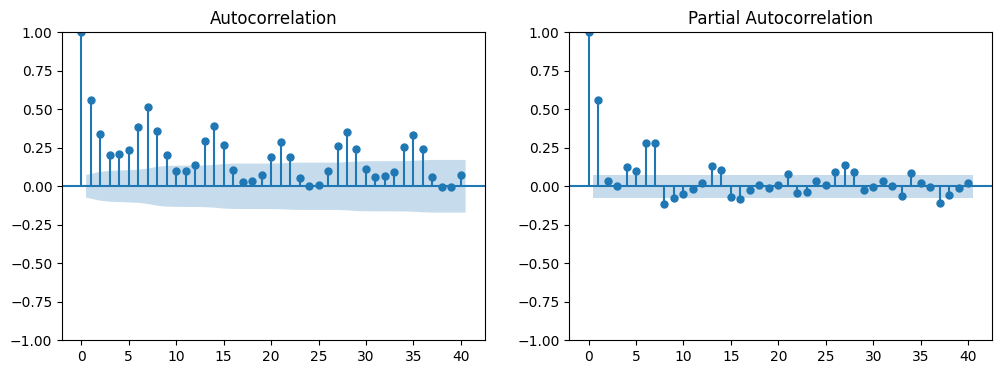

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df_92_train['value'], lags=40, ax=ax[0])
plot_pacf(df_92_train['value'], lags=40, ax=ax[1])
plt.show()

__Ответьте на следующие вопросы:__
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным?
___

Непонятно, стационарен ли ряд, так как тесты дают разные результаты (KPSS - на 5% уровне значимости отвергается гипотеза о стационарности, ADF - на любом разумном уровне значимости отвергается гипотеза о нестационарности) :/

Но если смотреть на график, кажется, что у ряда есть совсем небольшой восходящий тренд, то есть среднее возможно не постоянное во времени, а также разная дисперсия; склоняюсь к тому, что ряд не стационарен.

In [ ]:
stat_kpss, p_value_kpss, lags, critical_values_kpss = kpss(df_92_train['value'])
stat_adf, p_value_adf, usedlag, _, critical_values_adf, icbest = adfuller(df_92_train['value'])
print(f'KPSS p-value: {p_value_kpss}')
print(f'ADF p-value: {p_value_adf}\n')

KPSS p-value: 0.01
ADF p-value: 0.0014448425913405514



По графику ACF видны пики каждые примерно 7 дней - может говорить о недельной сезонности (возможно в пн/вс снимают деньги на неделю).

По графика самого ряда можно отметить нечто похожее на циклы, так как есть подъемы/спады в течение года, но с разной продолжительностью и выраженностью. Может объясняться какими-то экономическими причинами.

Попробуем разделить ряд на тренд, сезонность и остатки, а затем проверить остатки на стационарность.

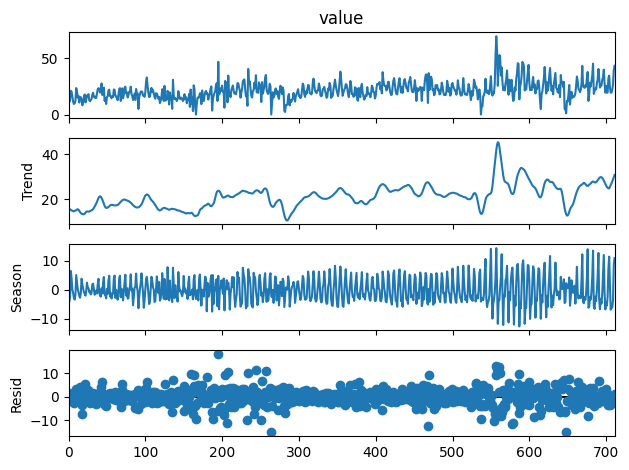

In [ ]:
res = STL(df_92_train["value"], period=7).fit()
res.plot()
plt.show()

In [ ]:
# остатки стационарны, сезонность и тренд скорее присутствуют
residuals = res.resid
statistic, p_value, lags, critical_values = kpss(residuals)
print(f"KPSS p-value: {p_value}")
statistic, p_value, usedlag, _, critical_values, icbest = adfuller(residuals)
print(f"ADF p-value: {p_value}")

KPSS p-value: 0.1
ADF p-value: 8.315297594656213e-18


#### Задание 2.2: Построение модели SARIMA (2 балла)

Пользуясь правилами отсюда: https://people.duke.edu/~rnau/arimrule.html, попробуйте подобрать параметры SARIMA модели, как мы делали это на семинаре.

Не забудьте о возможности использовать предобработку данных, например, логарифмирование и удаление выбросов (самое простое — это воспользоваться IQR: https://medium.com/@divyansh9144/iqr-interquartile-range-for-anomaly-detection-f9c568d1195f).

Если вы используете предобработку, то обязательно укажите, какую именно и почему.
___

Пользуюсь правилами 1 (дифференцирование, так как есть положительная автокорреляция на большом количестве лагов), 12 (если в ряду данных сезонность, то нужно использовать порядок сезонного дифференцирования). При этом по этому же 12 по правилу нельзя использовать более двух порядков общего дифференцирования (сезонного + несезонного).

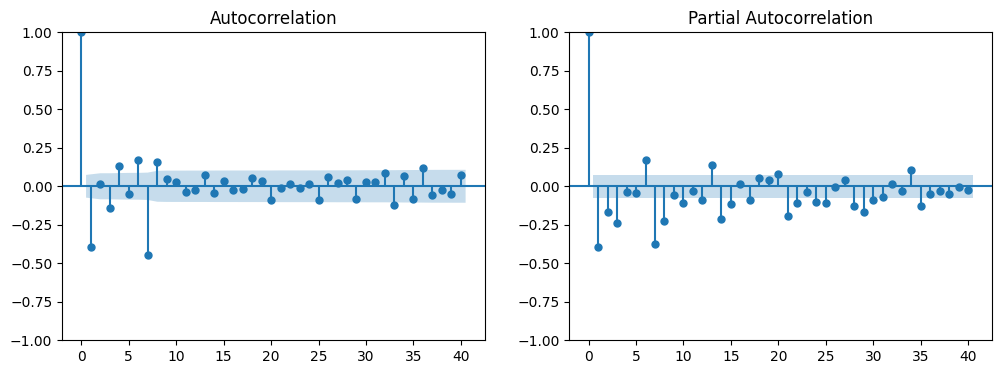

In [ ]:
diff_seas_series = df_92_train['value'].diff(7).dropna()
diff__diff_series = diff_seas_series.diff().dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff__diff_series, lags=40, ax=ax[0])
plot_pacf(diff__diff_series, lags=40, ax=ax[1])
plt.show()


- По правилу 7 (лаг, после которого ACF спадает, соответствует указанному количеству MA-членов) выбираем q = 1
- По правилу 13 (если автокорреляция разностного ряда отрицательна при запаздывании s, рассмотрите возможность добавления в модель SMA-члена) добавляем Q = 1, а P = 0

                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  712
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -2216.791
Date:                           Fri, 23 May 2025   AIC                           4439.582
Time:                                   20:01:38   BIC                           4453.214
Sample:                                        0   HQIC                          4444.853
                                           - 712                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6773      0.015    -45.729      0.000      -0.706      -0.648
ma.S.L7       -0.9351      0.013    -70.696

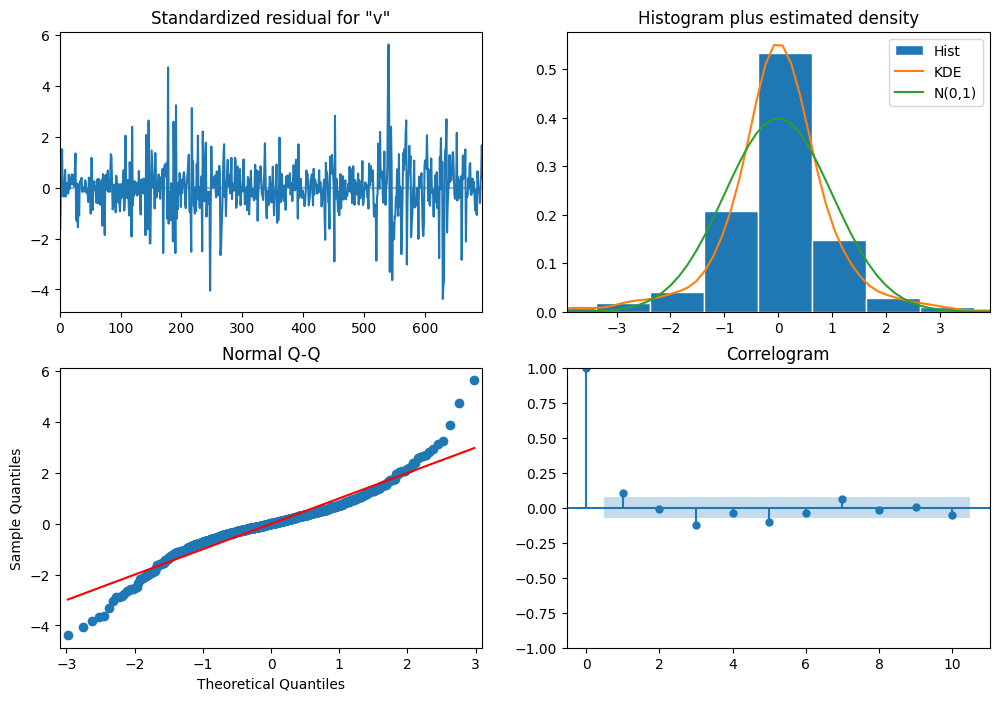

In [ ]:
# SARIMA(0, 1, 1)(0, 1, 1, 12)
model = SARIMAX(
    df_92_train['value'],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
model_fit = model.fit(disp=False)
print(model_fit.summary())

model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

Теперь попробуем логарифмирование и избавление от выбросов. Логарифмирование может "приблизить" остатки к нормальному распределению (например, если изначально распределение немного скошено, а также, чтобы убрать масштаб), а избавление от выбросов может помочь построить более устойчивую модель.

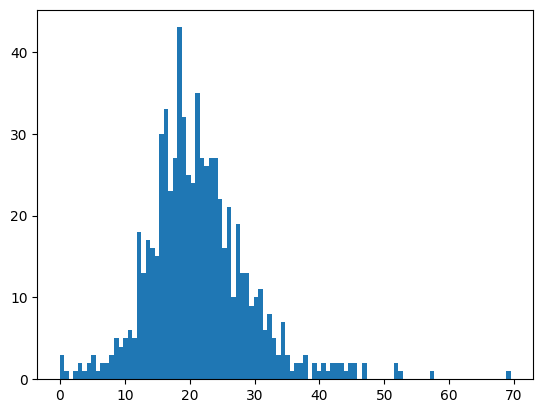

In [ ]:
# небольшая правосторонняя скошенность
plt.hist(df_92_train['value'], bins=100)
plt.show()

                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  712
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood                -278.132
Date:                           Fri, 23 May 2025   AIC                            562.265
Time:                                   20:01:41   BIC                            575.897
Sample:                                        0   HQIC                           567.536
                                           - 712                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7745      0.016    -48.765      0.000      -0.806      -0.743
ma.S.L7       -1.0294      0.016    -63.755

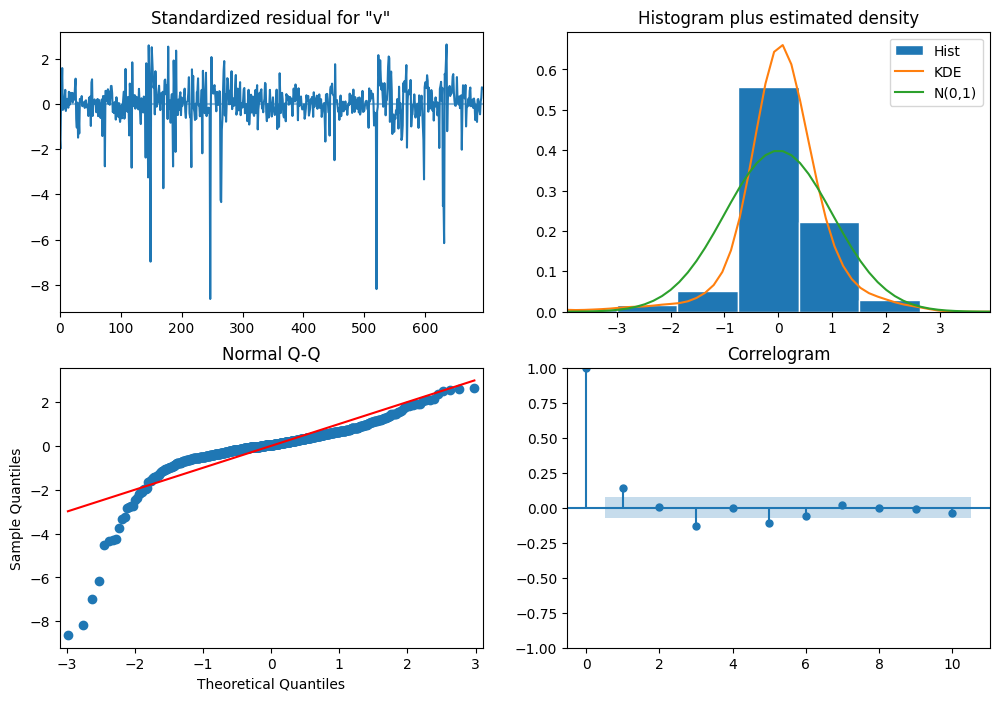

In [ ]:
# логарифмирование
log_92_train = np.log1p(df_92_train['value'])

model_log = SARIMAX(
    log_92_train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
result_log = model_log.fit(disp=False)
print(result_log.summary())

result_log.plot_diagnostics(figsize=(12, 8))
plt.show()

После лог стало только хуже (и остатки менее нормальные, и выше уверенность теста Ljung–Box в наличии автокорреляции остатков)

In [ ]:
# избавимся от выбросов
IQR = df_92_train['value'].quantile(0.75) - df_92_train['value'].quantile(0.25)
lower_bound = df_92_train['value'].quantile(0.25) - 1.5 * IQR
upper_bound = df_92_train['value'].quantile(0.75) + 1.5 * IQR
train_no_outliers = df_92_train[(df_92_train['value'] >= lower_bound) & (df_92_train['value'] <= upper_bound)]

                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  681
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -2053.815
Date:                           Fri, 23 May 2025   AIC                           4113.630
Time:                                   20:01:43   BIC                           4127.125
Sample:                                        0   HQIC                          4118.859
                                           - 681                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8399      0.018    -47.340      0.000      -0.875      -0.805
ma.S.L7       -0.7967      0.022    -35.631

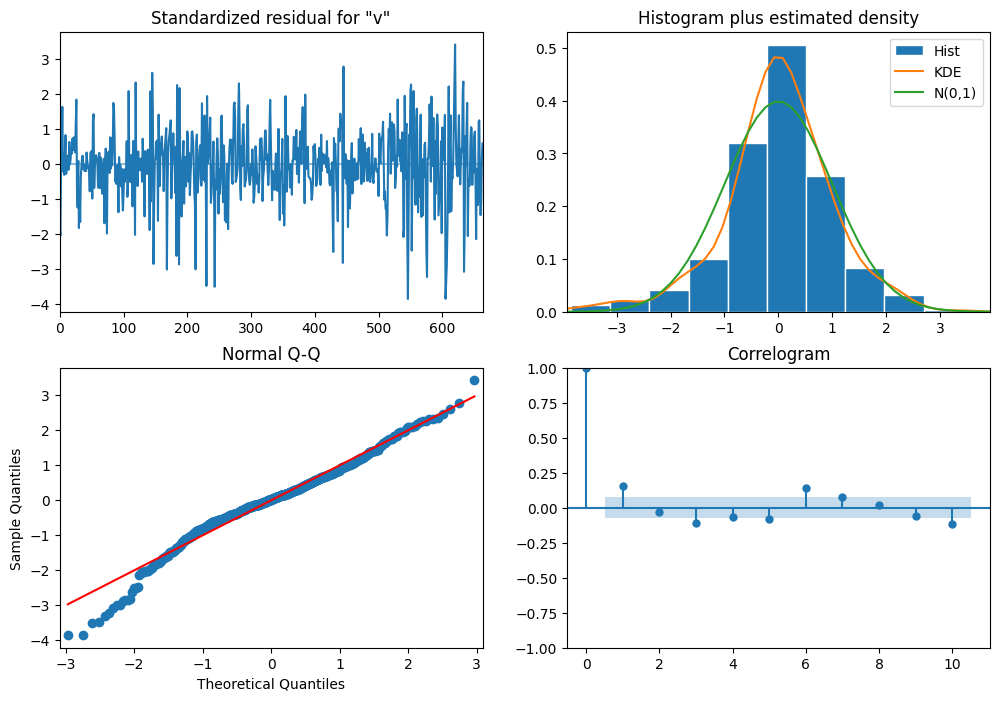

In [ ]:
model_no_outl = SARIMAX(
    train_no_outliers['value'],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
result_no_outl = model_no_outl.fit(disp=False)
print(result_no_outl.summary())

result_no_outl.plot_diagnostics(figsize=(12, 8))
plt.show()

#### Задание 2.3: Анализ остатков (0.5 баллов)

Постройте графики ACF и PACF остатков модели SARIMA. Проверьте, что в остатках нет значимых автокорреляций. Если они есть, то попробуйте объяснить, почему это происходит.

Проведите тест на стационарность остатков модели. Проведите тест на автокорреляцию остатков модели. Проинтерпретируйте результаты тестов. Если тесты показывают, что остатки нестационарны или в них есть автокорреляция, то попробуйте объяснить, почему это происходит.

In [ ]:
def stat_corr(result):
    # стационарность
    residuals = result.resid
    statistic, p_value, lags, critical_values = kpss(residuals)
    print(f"KPSS p-value: {p_value}")

    statistic, p_value, usedlag, _, critical_values, icbest = adfuller(residuals)
    print(f"ADF p-value: {p_value}")

    # автокорреляция
    lb_test = acorr_ljungbox(residuals, lags=range(1, 10), return_df=True)
    print(lb_test)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(residuals, lags=40, ax=ax[0])
    plot_pacf(residuals, lags=40, ax=ax[1])
    plt.show()


KPSS p-value: 0.1
ADF p-value: 2.8084108964727325e-26
     lb_stat  lb_pvalue
1   7.307031   0.006869
2   7.425629   0.024409
3  18.464262   0.000353
4  20.016424   0.000496
5  26.825844   0.000062
6  27.944612   0.000096
7  30.100800   0.000091
8  30.286421   0.000188
9  30.286450   0.000392


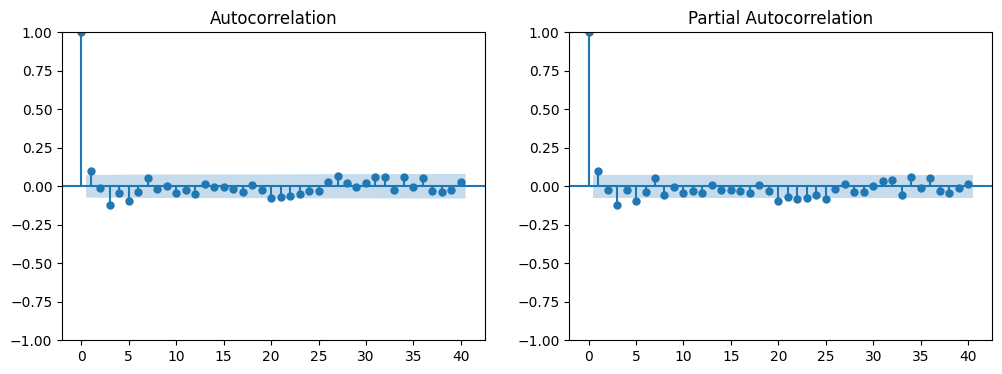

In [ ]:
# обычная модель
stat_corr(model_fit)

KPSS p-value: 0.1
ADF p-value: 8.612268109718976e-26
     lb_stat  lb_pvalue
1  10.394873   0.001264
2  10.417592   0.005468
3  19.060512   0.000266
4  19.286807   0.000690
5  26.714305   0.000065
6  29.319206   0.000053
7  30.189482   0.000088
8  30.189509   0.000196
9  30.281094   0.000393


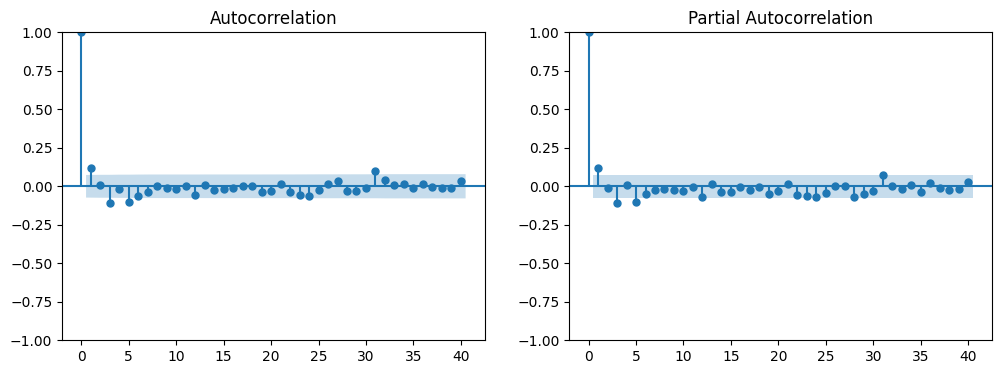

In [ ]:
# модель с логарифмом
stat_corr(result_log)

KPSS p-value: 0.1
ADF p-value: 7.818112869204424e-13
     lb_stat     lb_pvalue
1  15.383972  8.772927e-05
2  16.078205  3.225984e-04
3  23.741483  2.828475e-05
4  27.421635  1.633444e-05
5  31.793776  6.526840e-06
6  43.806326  8.075424e-08
7  46.875863  5.902011e-08
8  47.168702  1.423902e-07
9  50.003250  1.075724e-07


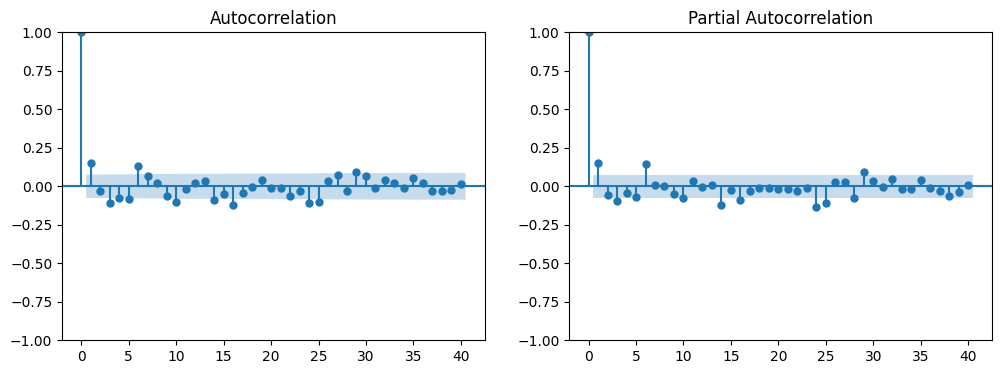

In [ ]:
# модель без выбросов
stat_corr(result_no_outl)

Тест KPSS - нулевая гипотеза: ряд стационарен. p-value 0.1, значит на 5% уровне значимости можно говорить о стационарности остатков, ADF также подтверждает это (нулевая гипотеза: ряд нестационарен, p-value << 0.01 - H0 отвергается, ряд не является нестационарным) для всех моделей, то есть остатки стационарны, что хорошо.

Если говорить об автокорреляции, то результаты теста Ljung-Box говорят о наличии автокорреляции (нулевая гипотеза об отсутствии автокорреляции для порядков лагов от 1 до 9 отвергается), как и графики ACF и PACF (есть точки, автокорреляция в которых выходит за пределы доверительного интервала).

Возможно, сезонная часть не полностью учла сезонные зависимости или же пропущены важные лаги (например, стоило взять order=(1,1,1)). Возможно наличие другой сезонности, которую я не заметила (возможно то, что я приняла за циклы, на самом деле сезонность).

#### Задание 2.4: Получение прогнозов и выводы (1 балл)

С помощью полученной модели постройте прогноз на тестовую выборку.

Постройте график прогноза и фактических значений. Сделайте выводы о том, насколько хорошо модель предсказывает временной ряд.

Посчитайте метрику MASE, которую мы имплементировали в начале ноутбука. Объясните, что она показывает и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE. Выводы по самому значению метрики делать не нужно.

In [ ]:
pred_first = model_fit.get_forecast(steps=len(df_92_test)).predicted_mean.reset_index(drop=True)
pred_log = result_log.get_forecast(steps=len(df_92_test)).predicted_mean.reset_index(drop=True)
pred_log = np.exp(pred_log)
pred_no_outl = result_no_outl.get_forecast(steps=len(df_92_test)).predicted_mean.reset_index(drop=True)

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=df_92_train["date"], y=df_92_train["value"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=df_92_test["date"], y=df_92_test["value"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=pred_first, name="Predictions_base", line=dict(color="green")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=pred_log, name="Predictions_log", line=dict(color="orange")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=pred_no_outl, name="Predictions_no_outl", line=dict(color="purple")
    )
)
fig.update_layout(
    title="Train/Test Split with Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [ ]:
mase_base = mase(pred_first, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_log = mase(pred_log, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_no_outl = mase(pred_no_outl, df_92_train['value'].values, df_92_test['value'].values, 7)
print(f'MASE для обычной модели: {mase_base}')
print(f'MASE для модели с логарифмом: {mase_log}')
print(f'MASE для модели без выбросов: {mase_no_outl}')

MASE для обычной модели: 1.3775658874827412
MASE для модели с логарифмом: 1.189483131121433
MASE для модели без выбросов: 1.4308925889786466


MASE измеряет, насколько хорошо предсказывает модель по сравнению с наивным сезонным прогнозом. Если значение меньше 1 - лучше, = 1 - также, больше 1 - хуже. В данном случае логарифмическая модель справилась лучше всего, но все три модели предсказывают хуже наивного прогноза :(

Метрика MAE не так полезна, потому что она не учитывает возможные различия в масштабе у временных рядов. MAPE, во-первых, не используема, если таргет имеет нулевое значение (так как происходит деление на него), во-вторых, штрафует переоценку и недооценку по-разному, так как для заниженных прогнозов ошибка не более 100%, а для завышенных нет верхнего предела (может быть выгоднее занижать прогнозы).

Метрика MASE учитывает масштаб данных и не имеет проблем асимметричности.

### Задание 3. Построение бейзлайнов на всех рядах и автоматический подбор параметров (2 балла)

#### Задание 3.1: Запуск бейзлайнов (1 балл)
Давайте будем использовать statsforecast для бейзлайнов, так же как мы делали это на семинаре: https://nixtlaverse.nixtla.io/statsforecast/index.html

Постройте прогнозы на всех рядах с помощью следующих бейзлайнов:
- Naive
- Seasonal Naive
- AutoARIMA
- еще 2 на ваш выбор (например, ETS, Theta, TBATS или другие, которые вам нравятся). Кратко опишите суть выбранных моделей.
___

ETS - модель, учитывающая три компонента ряда: ошибка, тренд и сезонность. Основана на экспоненциальном сглаживании.

Theta - модель, основанная на разложении ряда на теты — линейные компоненты с разной кривизной. Прогноз строится как комбинация нескольких тета-линий, каждая из которых моделирует разные аспекты тренда и сезонности.

In [ ]:
# Переименуйте колонки, так как библиотека требует названия "unique_id", "y", "ds"
df_train = df_train.rename(columns={
    'id': 'unique_id',
    'value': 'y',
    'date': 'ds',
})

df_test = df_test.rename(columns={
    'id': 'unique_id',
    'value': 'y',
    'date': 'ds',
})
# Инициализируйте модели
models_baseline = StatsForecast(
    models=[
        models.SeasonalNaive(season_length=7),
        models.Naive(),
        models.AutoARIMA(season_length=7),
        models.AutoETS(season_length=7),
        models.AutoTheta(season_length=7),
    ],
    freq='D',
    n_jobs=-1,
    verbose=True,
)

# Получите прогнозы
df_pred = models_baseline.forecast(df=df_train, h=len(df_92_test))

Forecast:   0%|          | 0/111 [Elapsed: 00:00]

#### Задание 3.2: Анализ результатов (1 балл)

Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Выведите метрики MASE.

Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?

Смогли ли вы руками подобрать гиперпараметры для SARIMA модели лучше, чем автоматический подбор в библиотеке? Если да, то вы огромный молодец! Если нет, то не расстраивайтесь, так бывает.

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=df_92_train["date"], y=df_92_train["value"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=df_92_test["date"], y=df_92_test["value"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['Naive'], name="Naive", line=dict(color="green")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['SeasonalNaive'], name='SeasonalNaive', line=dict(color="orange")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoARIMA'], name="AutoARIMA", line=dict(color="purple")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoETS'], name="AutoETS", line=dict(color="pink")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoTheta'], name="AutoTheta", line=dict(color="brown")
    )
)

fig.update_layout(
    title="Train/Test Split with Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=df_92_test["date"], y=df_92_test["value"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['Naive'], name="Naive", line=dict(color="green")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['SeasonalNaive'], name='SeasonalNaive', line=dict(color="orange")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoARIMA'], name="AutoARIMA", line=dict(color="purple")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoETS'], name="AutoETS", line=dict(color="pink")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=df_pred['AutoTheta'], name="AutoTheta", line=dict(color="brown")
    )
)

fig.update_layout(
    title="Test and Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [ ]:
df_92_pred = df_pred[df_pred['unique_id'] == '92']
mase_naive = mase(df_92_pred['Naive'].values, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_seasonal_naive = mase(df_92_pred['SeasonalNaive'].values, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_autoarima = mase(df_92_pred['AutoARIMA'].values, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_autoets = mase(df_92_pred['AutoETS'].values, df_92_train['value'].values, df_92_test['value'].values, 7)
mase_autotheta = mase(df_92_pred['AutoTheta'].values, df_92_train['value'].values, df_92_test['value'].values, 7)
print(f'MASE для наивного прогноза: {mase_naive}')
print(f'MASE для сезонного наивного прогноза: {mase_seasonal_naive}')
print(f'MASE для AutoARIMA: {mase_autoarima}')
print(f'MASE для AutoETS: {mase_autoets}')
print(f'MASE для AutoTheta: {mase_autotheta}')

MASE для наивного прогноза: 3.2468839551723416
MASE для сезонного наивного прогноза: 1.1272963460381045
MASE для AutoARIMA: 1.38885171280105
MASE для AutoETS: 1.1738810299435642
MASE для AutoTheta: 1.3454700893594964


Лучше всего для данного временного ряда - сезонный наивный прогноз. Из моделей, которые я построила ранее, только логарифмическая модель выделяется (она сработала примерно как ETS), остальные примерно на среднем и хуже уровне. Но в целом модельки хорошо предсказывают сезонность.


Постройте датафрейм с MASE для всех бейзлайнов (агрегированный по всем рядам). Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит?

In [ ]:
naive, snaive, arima, ets, theta = [], [], [], [], []
for i in df_pred.unique_id.unique():
    df_pred_ts = df_pred[df_pred['unique_id'] == i]
    df_test_ts = df_test[df_test['unique_id'] == i]
    df_train_ts = df_train[df_train['unique_id'] == i]
    mase_naive = mase(df_pred_ts['Naive'].values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_seasonal_naive = mase(df_pred_ts['SeasonalNaive'].values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_autoarima = mase(df_pred_ts['AutoARIMA'].values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_autoets = mase(df_pred_ts['AutoETS'].values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_autotheta = mase(df_pred_ts['AutoTheta'].values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    naive.append(mase_naive)
    snaive.append(mase_seasonal_naive)
    arima.append(mase_autoarima)
    ets.append(mase_autoets)
    theta.append(mase_autotheta)

df_mase = pd.DataFrame({'Naive': [np.mean(naive)],
                        'SeasonalNaive': [np.mean(snaive)],
                        'AutoARIMA': [np.mean(arima)],
                        'AutoETS': [np.mean(ets)],
                        'AutoTheta': [np.mean(theta)]})

In [ ]:
df_mase.T

,0
Naive,2.966316
SeasonalNaive,1.008258
AutoARIMA,0.847944
AutoETS,0.857932
AutoTheta,0.866288


AutoARIMA с ошибкой 0.848 — лучший показатель, то есть он точнее всего предсказывает временные ряды в данном датасете. Хуже всего - наивный. Наивный просто повторяет последнее известное значение без учёта тренда и сезонности, поэтому он плохо работает на наших рядах с явно выраженной сезонностью. Остальные учитывают сезонность (а кроме SeasonalNaive еще и тренд)  - поэтому показали себя намного лучше. В целом ARIMA, ETS и Theta не сильно разнятся в значениях метрик, но видимо ARIMA чуть лучше подходит под наши данные.

Постройте графики фактических значений и прогнозов самого сильного бейзлайна для еще 3-х каких-нибудь рядов и ответьте на следующие вопросы:
- Есть ли среди них такие, которые предсказываются хуже остальных?
- Есть ли среди них такие, которые предсказываются лучше остальных?

In [ ]:
for i in ['23', '77', '104']:

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df_test.loc[df_test['unique_id'] == i, 'ds'],
            y=df_test.loc[df_test['unique_id'] == i, 'y'],
            name='Test',
            line=dict(color='orange'),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_pred.loc[df_pred['unique_id'] == i, 'ds'],
            y=df_pred.loc[df_pred['unique_id'] == i, 'AutoARIMA'],
            name='Forecast AutoARIMA',
            line=dict(color='blue', dash='dash'),
        )
    )
    fig.update_layout(
        title=f'TimeSeries {i}: Test and Predictions',
        xaxis_title='Date',
        yaxis_title='Value'
    )
    fig.show()

В целом на всех трех рядах модель хорошо предсказывает сезонность, но не может уловить колебания/отклонения от "идеальной" сезонности. На первый взгляд не выделяются худшие или лучшие по предсказаниям ряды из этих трех, везде есть какие то отклонения примерно в одинаковом количестве.

### Задание 4. ML & DL модели (3 балла)

Здесь хочется дать вам полную свободу действий.

Вам нужно будет выбрать одну из ML моделей и одну из DL моделей (старайтесь не повторять один в один решение из семинара, а, если повторяете, то попробуйте, например, перебрать параметры DL модели, оптимизации, препроцессинга / добавить экзогенные признаки (актуально для MIMO стратегии) и т. д.) и построить прогнозы для всех временных рядов на тестовой выборке. __Ваша цель (желательная, но необязательная) — улучшить MASE, полученный с помощью бейзлайнов.__

__Результат задания — мини-отчет по тому, что вы попробовали, что получилось и что не получилось.__ По одному баллу дается за работу с данными (предобработка, генерация дополнительных признаков), за применение ML и DL моделей и интерпретацию полученных с помощью них результатов. Не забудьте кратко описать суть выбранных моделей (особенно, если речь идет о DL моделях).

Вы можете использовать любые модели и библиотеки (`tsfresh` для извлечения признаков, `Tsururu` / `ETNA` / `darts` для использования предобработки, стратегий, моделей и т. д.).
___

Начнем с базовой модели без предобработки.

In [ ]:
from darts import TimeSeries
from darts import concatenate
from darts.models import LinearRegressionModel
from darts.dataprocessing.transformers import Diff, Scaler
from darts.models.forecasting.nbeats import NBEATSModel
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
series_list_train = []
series_list_test = []

for series_id, group in df_train.groupby('unique_id'):
    ts = TimeSeries.from_dataframe(group, time_col='ds', value_cols='y', freq='D')
    series_list_train.append(ts)

for series_id, group in df_test.groupby('unique_id'):
    ts = TimeSeries.from_dataframe(group, time_col='ds', value_cols='y', freq='D')
    series_list_test.append(ts)

multiser_train = concatenate(series_list_train, axis=1)
multiser_test = concatenate(series_list_test, axis=1)

In [ ]:
model = LinearRegressionModel(lags=79)
model.fit(multiser_train)

forecast = model.predict(79)

In [ ]:
df_forecast = forecast.to_dataframe(time_as_index=False)

In [ ]:
mase_base = []
for i in range(110):
    current_pred_ts = df_forecast.iloc[:, i + 1]
    df_test_ts = df_test[df_test['unique_id'] == f'{i}']
    df_train_ts = df_train[df_train['unique_id'] == f'{i}']
    mase_ = mase(current_pred_ts.values, df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_base.append(mase_)
print(np.mean(mase_base))

2.0676154222765883


Далее предобработка

In [ ]:
scaler = Scaler()
diff = Diff(lags=1)

mv_train_sc = scaler.fit_transform(multiser_train)
mv_train_sc = diff.fit_transform(multiser_train)
mv_test_sc = scaler.transform(multiser_test)
mv_test_sc = diff.transform(multiser_test)

In [ ]:
model = LinearRegressionModel(lags=79)
model.fit(mv_train_sc)

forecast_lr = model.predict(79)

In [ ]:
mase_base = []
combined = mv_train_sc.concatenate(forecast_lr)
forecast_restored = diff.inverse_transform(combined).slice(forecast_lr.start_time(), forecast_lr.end_time())
for i in range(110):
    current_pred_ts = forecast_restored.univariate_component(i)[-79:]
    df_test_ts = df_test[df_test['unique_id'] == f'{i}']
    df_train_ts = df_train[df_train['unique_id'] == f'{i}']
    mase_ = mase(current_pred_ts.values(), df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_base.append(mase_)
print(np.mean(mase_base))

2.547015443984417


In [ ]:
model = NBEATSModel(
    input_chunk_length=150,
    output_chunk_length=79,
    n_epochs=20,
    random_state=42,
    lr_scheduler_cls=CosineAnnealingLR,
    lr_scheduler_kwargs={"T_max": 20}
)
model.fit(mv_train_sc)
forecast = model.predict(79)

INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 483 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 64-bits; casting model to float64.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 138 M  | train
--------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
mase_base = []
combined_nb = mv_train_sc.concatenate(forecast)
forecast_restored_nb = diff.inverse_transform(combined_nb).slice(forecast.start_time(), forecast.end_time())
for i in range(110):
    current_pred_ts = forecast_restored_nb.univariate_component(i)[-79:]
    df_test_ts = df_test[df_test['unique_id'] == f'{i}']
    df_train_ts = df_train[df_train['unique_id'] == f'{i}']
    mase_ = mase(current_pred_ts.values(), df_train_ts['y'].values, df_test_ts['y'].values, 7)
    mase_base.append(mase_)
print(np.mean(mase_base))

3.5475568360366507



Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Постройте графики фактических значений и прогнозов для 3-х рядов из предыдущего задания. Стали ли прогнозы лучше отражать реальность?

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=df_92_test["date"], y=df_92_test["value"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=forecast_restored.univariate_component(92)[-79:].values().flatten(), name="LinearRegression", line=dict(color="green")
    )
)
fig.add_trace(
    go.Scatter(
        x=df_92_test["date"], y=forecast_restored_nb.univariate_component(92)[-79:].values().flatten(), name="NBEATS", line=dict(color="blue")
    )
)

fig.update_layout(
    title="Test and Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [ ]:
for i in ['23', '77', '104']:

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df_test.loc[df_test['unique_id'] == i, 'ds'],
            y=df_test.loc[df_test['unique_id'] == i, 'y'],
            name='Test',
            line=dict(color='orange'),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_test.loc[df_test['unique_id'] == i, 'ds'],
            y=forecast_restored.univariate_component(int(i))[-79:].values().flatten(),
            name='Forecast LinearRegression',
            line=dict(color='blue', dash='dash'),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_test.loc[df_test['unique_id'] == i, 'ds'],
            y=forecast_restored_nb.univariate_component(int(i))[-79:].values().flatten(),
            name='Forecast NBEATS',
            line=dict(color='red', dash='dash'),
        )
    )
    fig.update_layout(
        title=f'TimeSeries {i}: Test and Predictions',
        xaxis_title='Date',
        yaxis_title='Value'
    )
    fig.show()

Я решила использовать в качестве ML модели линейную регрессию. Сначала я обучила без предобработки, получилось mase около 2. Затем добавила scaler и дифференцирование, что только ухудшило модель :/ Тогда я перешла к DL модели - NBEATS (в архитектуре несколько полносвязных слоев). Начала обучать на необработанных данных - было медленно и плохо, поэтому решила не дожидаться и обработать данные. Обучила на 10 эпохах - mase 3.6..... Но все время ошибка снижалась, поэтому я решила попробовать scheduler CosineAnnealingLR и увеличить количество эпох до 20. Тогда mase стало 3.54 (у меня вылетело на конце последней эпохи...). Думаю можно было добавить еще признаки, другие преобразования (Бокс-Кокс, например), подольше обучить нейронку, но как итог - бейзлайны у меня получились лучше всего :)